# 查看语料

In [1]:
words = open("names.txt", 'r').read().splitlines()
len(words)

32033

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
min(len(w) for w in words), max(len(w) for w in words), sum(len(w) for w in words)/len(words)

(2, 15, 6.122217712983486)

# Bigram

对于字符级别的语言模型来说, `Bigram`意味着每次只处理两个字符（而不是word级别是两个分词）
+ 即每次只给定一个字符，然后预测下一个字符 → 总是根据前一个(previous)字符预测下一个(next)字符
+ 相当于只对局部结构建模（也可以理解为: 建模的窗口只有2个字符）, 会导致忽略掉很多其他信息

In [9]:
for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>'] 
    # 添加首尾
    for ch1, ch2 in zip(chs, chs[1:]):
        # 这里的遍历, 只要有一个列表到头了,整个遍历过程就停止了
        print(ch1,ch2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>


构建一种字典结构，来统计每个bigram对出现的次数

In [13]:
b = {}
for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) + 1
        # print(ch1,ch2)
b

{('<S>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<E>'): 3,
 ('<S>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<S>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

In [14]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [17]:
sorted_b = sorted(b.items(), key = lambda kv:kv[1])  # 按照值排序, 默认升序
sorted_b[0], sorted_b[-1]

((('q', 'r'), 1), (('n', '<E>'), 6763))

将这些bigram的出现次数放在二维数组中会更方便，
+ 比如：用行(row)表示bigram的第一个字符，用列(column)表示bigram的第二个字符
+ 这里也很好操作，对于字符级来说(这个语料只涉及26个字母 + 2个起始标志字符)，因此也就是一个 28行，28列的矩阵，直接每个字符映射一个整数，作为行号/列号即可
+ 计算也可以发现，上面只有627种组合，小于 28*28的组合，即：有些组合是不存在的，直接统计次数设置为0即可

只是因为这个语料比较简单，如果是更常规的英文自然语料，至少得是 ASCII 127个字符，那么矩阵就变成了 129*129了

如果是纯中文，就得变成6800左右的一个方阵了

In [18]:
len(b), (26+2)*(26+2)

(627, 784)

In [23]:
import torch
a= torch.zeros([3,5])
print(a, a.dtype)
# torch创建tensor的时候 默认是单精度浮点数，这里需要表示次数，因此，需要改成 torch.int32
a= torch.zeros([3,5], dtype=torch.int32)
print(a, a.dtype)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]) torch.float32
tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32) torch.int32


In [30]:
for i,num in enumerate(['a', 'b', 'c']):
    print(i, num)

0 a
1 b
2 c


In [36]:
# 为了能够把字符/单词表示成整数， 这里需要构建 字符到整数的映射字典，以及整数到字符的映射字典
chars = sorted(list(set(''.join(words))))
print(chars[:3],len(chars))

# string/character to index
stoi = {s:i for i,s in enumerate(chars)}
stoi['<S>'] = 26
stoi['<E>'] = 27

itos = {i:s for s,i in stoi.items()}
# itos = {i:s for i,s in enumerate(chars)}
# itos[26] = '<S>'
# itos[27] = '<E>'
print(stoi["a"])
print(itos[0])

['a', 'b', 'c'] 26
0
a


In [33]:
N = torch.zeros([28,28], dtype=torch.int32)
for w in words:
    chs = ['<S>'] + list(w) + ['<E>'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        row = stoi[ch1]
        col = stoi[ch2]
        N[row,col]+=1

上面在统计 字典b的 次数的时候，有 ： `((('q', 'r'), 1), (('n', '<E>'), 6763))`， 这里验证下

In [34]:
row = stoi['n']
col = stoi['<E>']
N[row,col]

tensor(6763, dtype=torch.int32)

(-0.5, 27.5, 27.5, -0.5)

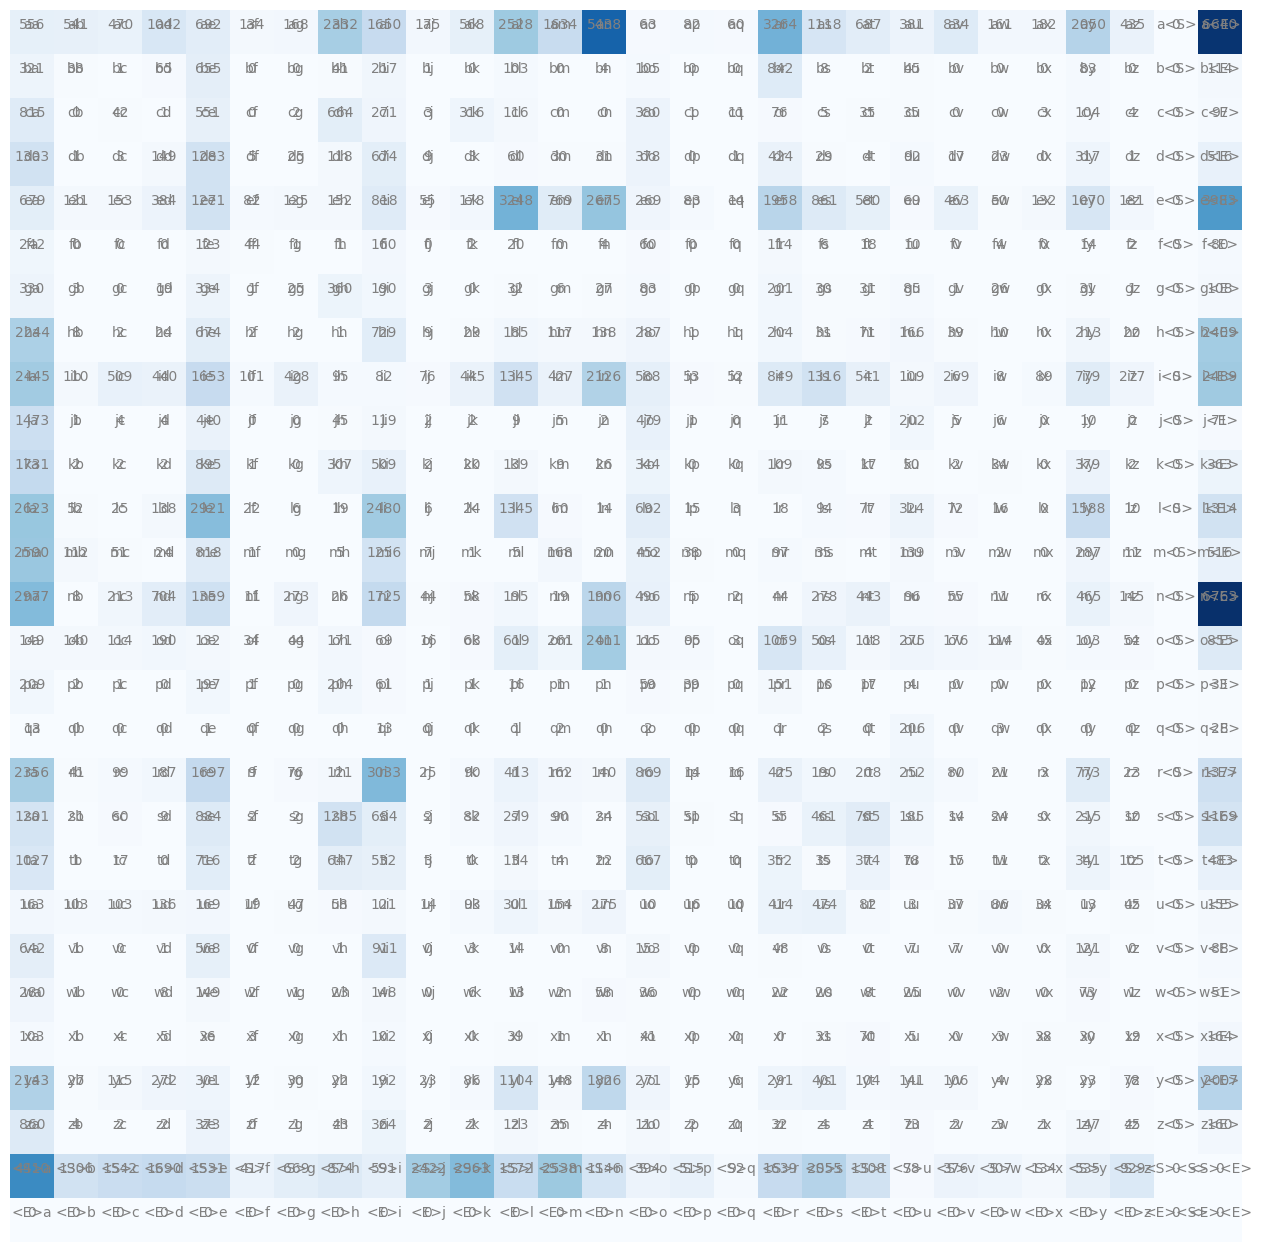

In [40]:
import matplotlib.pyplot as plt
%matplotlib inline
# plt.imshow(N)  # 这样直接显示会很丑

plt.figure(figsize=(16,16))
plt.imshow(N, cmap = 'Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i]+itos[j]
        plt.text(j, i, chstr, ha = 'center', va = 'bottom', color = 'gray')
        plt.text(j, i, N[i,j].item(), ha = 'center', va = 'bottom', color = 'gray')
plt.axis('off')

以前用pandas绘图的：[动手学深度学习V2.0(Pytorch)——23. LeNet（mnist）->2.1 灰度图显示mnist数字](https://stitch.blog.csdn.net/article/details/121845440)

In [37]:
import pandas as pd
df = pd.DataFrame(N)
df.columns = df.columns.map(itos)
df.index = df.index.map(itos)
df.style.set_properties(**{'font-size':'4pt'}).background_gradient('Greys')

,a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y,z,,
a,556,541,470,1042,692,134,168,2332,1650,175,568,2528,1634,5438,63,82,60,3264,1118,687,381,834,161,182,2050,435,0,6640
b,321,38,1,65,655,0,0,41,217,1,0,103,0,4,105,0,0,842,8,2,45,0,0,0,83,0,0,114
c,815,0,42,1,551,0,2,664,271,3,316,116,0,0,380,1,11,76,5,35,35,0,0,3,104,4,0,97
d,1303,1,3,149,1283,5,25,118,674,9,3,60,30,31,378,0,1,424,29,4,92,17,23,0,317,1,0,516
e,679,121,153,384,1271,82,125,152,818,55,178,3248,769,2675,269,83,14,1958,861,580,69,463,50,132,1070,181,0,3983
f,242,0,0,0,123,44,1,1,160,0,2,20,0,4,60,0,0,114,6,18,10,0,4,0,14,2,0,80
g,330,3,0,19,334,1,25,360,190,3,0,32,6,27,83,0,0,201,30,31,85,1,26,0,31,1,0,108
h,2244,8,2,24,674,2,2,1,729,9,29,185,117,138,287,1,1,204,31,71,166,39,10,0,213,20,0,2409
i,2445,110,509,440,1653,101,428,95,82,76,445,1345,427,2126,588,53,52,849,1316,541,109,269,8,89,779,277,0,2489
j,1473,1,4,4,440,0,0,45,119,2,2,9,5,2,479,1,0,11,7,2,202,5,6,0,10,0,0,71
